### $\color{indianred}{\text{ASTROSTATISTIKA - v7}} $

<hr style="border: none; height: 2px; background-color: indianred; opacity: 0.5;" />

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm, poisson, cauchy
from scipy.stats import kstwo, kstest, ks_2samp
from scipy.integrate import quad
from scipy import optimize
import seaborn as sb
import matplotlib
from sklearn.neighbors import KernelDensity
from time import time
matplotlib.rcParams.update({"text.usetex": False, "font.size" : 10, "font.family": "monospace"})

Pretpostavljamo da je poznata neka jednoparametarska uzoračka raspodjela. Uzorke $\{x_i\}$ obično prikazujemo histogramom, ali tu se javljaju određeni problemi.

In [8]:
np.random.seed(0)
N = 1000

# kombinacija Košijevih raspodjela
mu_gamma_f = [(5, 1.0, 0.1),
              (7, 0.5, 0.5),
              (9, 0.1, 0.1),
              (12, 0.5, 0.2),
              (14, 1.0, 0.1)]

pdf = lambda x: sum([f * cauchy(mu, gamma).pdf(x) for (mu, gamma, f) in mu_gamma_f])

x = np.concatenate([cauchy(mu, gamma).rvs(int(f * N)) for (mu, gamma, f) in mu_gamma_f]) 

np.random.shuffle(x)
x = x[x > -10]
x = x[x < 30]
print(len(x))

981


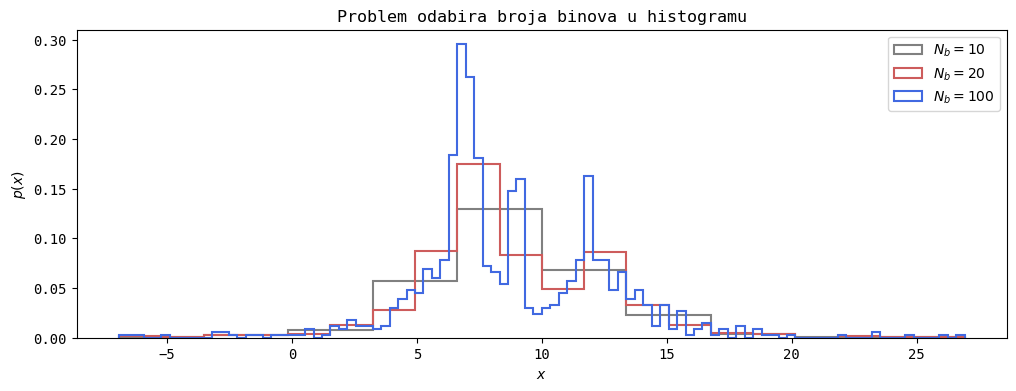

In [11]:
plt.figure(figsize=(12,4))
plt.hist(x, bins=10,histtype='step', density=True, color='gray', label=r'$N_b=10$', lw=1.5)
plt.hist(x, bins=20,histtype='step', density=True, color='indianred', label=r'$N_b=20$', lw=1.5)
plt.hist(x, bins=100,histtype='step', density=True, color='royalblue', label=r'$N_b=100$', lw=1.5)
plt.xlabel(r'$x$')
plt.ylabel(r'$p(x)$')
plt.legend()
plt.title(r'Problem odabira broja binova u histogramu')
plt.show()

Skup podataka $\{x_i\}$ je ostao isti, ali mijenjanje *hiperparametara* histograma je jako uticalo na izgled raspodjele gustine vjerovatnoće. Ovo se može popraviti npr. time da svaki stubić sadrži jednak broj podataka.

In [4]:
bins100 = np.append(np.sort(x)[::100], np.max(x)) 
bins30 = np.append(np.sort(x)[::30], np.max(x))
print(len(bins100),len(bins30))

11 34


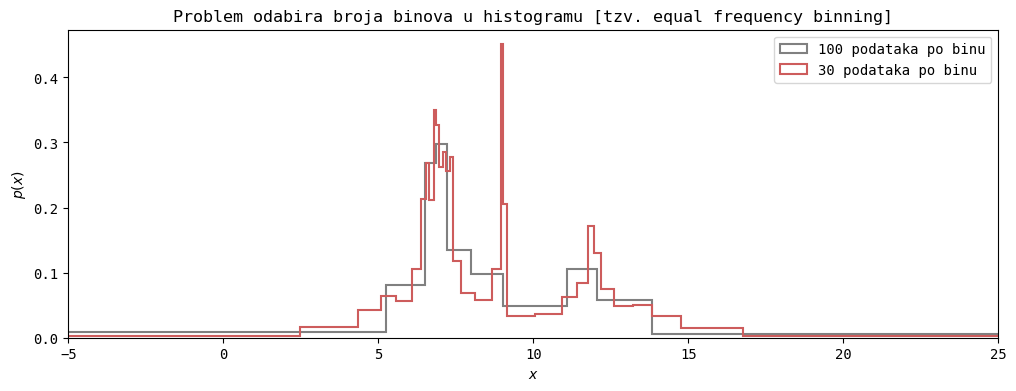

In [ ]:
plt.figure(figsize=(12,4))
plt.hist(x, bins=bins100, histtype='step', density=True, color='gray', label='100 podataka po binu', lw=1.5)
plt.hist(x, bins=bins30, histtype='step', density=True, color='indianred', label='30 podataka po binu', lw=1.5)
plt.xlim(-5,25)
plt.xlabel(r'$x$')
plt.ylabel(r'$p(x)$')
plt.legend()
plt.title(r'Problem odabira broja binova u histogramu [tzv. equal frequency binning]')
plt.show()

U ovom kontekstu, postoje dva korisna pravila. Prvo je *Skotovo pravilo*, koje predlaže optimalnu širinu stubića preko $\sigma$ (za $\mathcal{N}$):

$$
\Delta_b = \frac{3.5\sigma}{N^{1/3}}.
$$

Ukoliko je $\sigma$ nedefinisano (npr. raspodjela je Košijeva), koristi se *Fridman-Diakonisovo pravilo*:

$$
\Delta_b = \frac{2(q_{75} - q_{25})}{N^{1/3}} = \frac{2.7\sigma_G}{N^{1/3}}.
$$

35


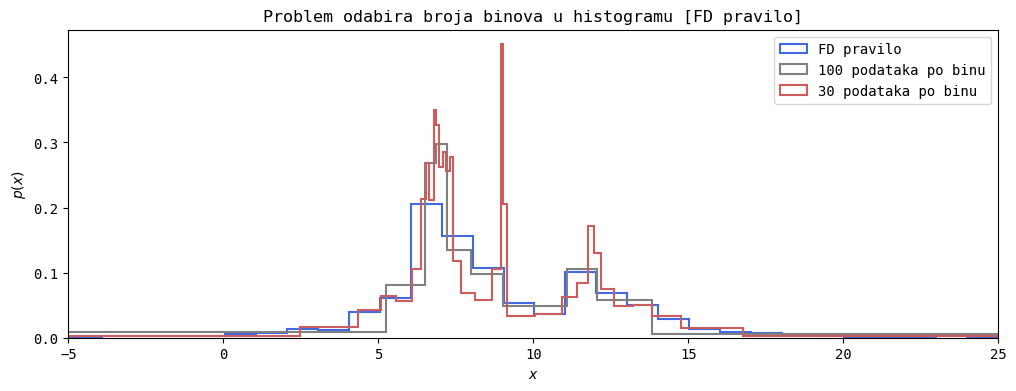

In [13]:
q75, q25 = np.percentile(x, [75, 25])
delta_b = 2 * (q75 - q25) / len(x)**(1/3)
bins_fd = np.arange(x.min(), x.max() + delta_b, delta_b)
print(len(bins_fd))

plt.figure(figsize=(12,4))
plt.hist(x, bins=bins_fd, histtype='step', density=True, color='royalblue', lw=1.5, label='FD pravilo')
plt.hist(x, bins=bins100, histtype='step', density=True, color='gray', lw=1.5, label='100 podataka po binu')
plt.hist(x, bins=bins30, histtype='step', density=True, color='indianred', lw=1.5, label='30 podataka po binu')
plt.xlim(-5,25)
plt.xlabel(r'$x$')
plt.ylabel(r'$p(x)$')
plt.legend()
plt.title(r'Problem odabira broja binova u histogramu [FD pravilo]')
plt.show()

Mane histograma je lako uočiti ako je dat tzv. *rug* grafik koji prikazuje prave pozicije individualnih podataka.

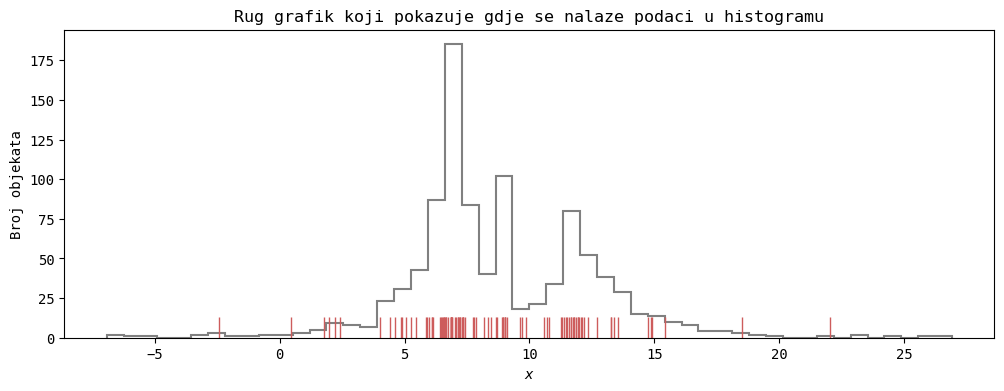

In [ ]:
plt.figure(figsize=(12,4))
plt.hist(x, bins=50, histtype='step', color='gray', lw=1.5)
plt.plot(x[:100], 0*x[:100], '|', color='indianred', markersize=30, lw=2) 
plt.xlabel(r'$x$')
plt.ylabel(r'Broj objekata')
plt.title(r'Rug grafik koji pokazuje gdje se nalaze podaci u histogramu')
plt.show()

---

Tzv. procjena gustine jezgrom (eng. *Kernel Density Estimation* KDE) predstavlja svaki podatak ne kao $\delta$-funkciju, već preko raspodjele (npr. normalnu). Te pojedinačne raspodjele (tzv. jezgra) se sabiraju i daju raspodjelu gustine vjerovatnoće. Prednost KDE u tome što kombinuje:

1. histogram - daje relativnu visinu raspodjele,

2. *rug plot* - centrira tačke na stvarnim lokacijama, a ne unutar proizvoljnih binova.

Kao jezgro može se koristiti skoro svaka raspodjela, ali najčešće su Gausovo i *Epanečnikovljevo jezgro*. Mana Gausovog jezgra su beskonačni repovi - svaka tačka ima konačnu vjerovatnoću da bude bilo gdje. Epanečnikovljevo jezgro ima odrezane repove. Ostaje problem odabira širine jezgra - tzv. *bandwidth* ($\varepsilon$). U praksi je to ključni parametar KDE; tačan oblik jezgra je manje važan.

In [22]:
xg = np.linspace(x.min(),x.max(),1000)  

def kde_sklearn(d, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, kernel=kernel)
    kde_skl.fit(d[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xg[:, np.newaxis])

    return np.exp(log_pdf)

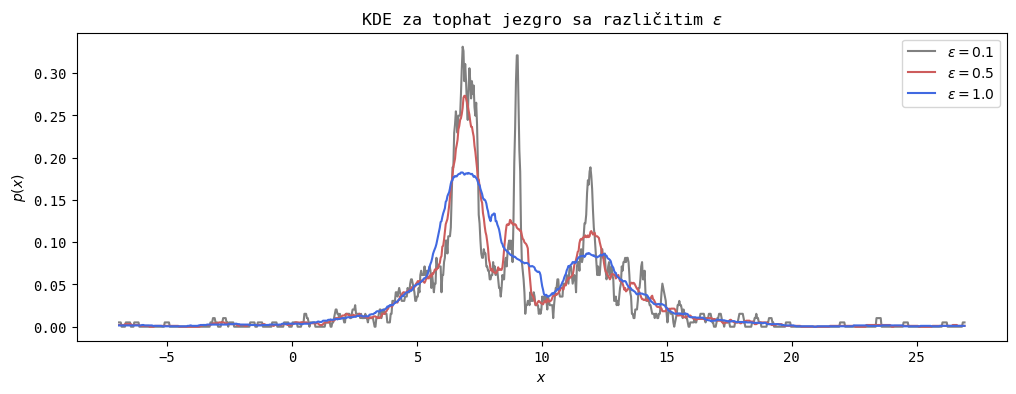

In [30]:
tophat01 = kde_sklearn(x, bandwidth=0.1, kernel="tophat") 
tophat05 = kde_sklearn(x, bandwidth=0.5, kernel="tophat") 
tophat10 = kde_sklearn(x, bandwidth=1.0, kernel="tophat") 

plt.figure(figsize=(12,4))
plt.plot(xg, tophat01, color='gray', label=r'$\epsilon = 0.1$', lw=1.5)
plt.plot(xg, tophat05, color='indianred', label=r'$\epsilon = 0.5$', lw=1.5)
plt.plot(xg, tophat10, color='royalblue', label=r'$\epsilon = 1.0$', lw=1.5)
plt.xlabel(r'$x$')
plt.ylabel(r'$p(x)$')
plt.legend()
plt.title(r'KDE za tophat jezgro sa različitim $\varepsilon$')
plt.show()

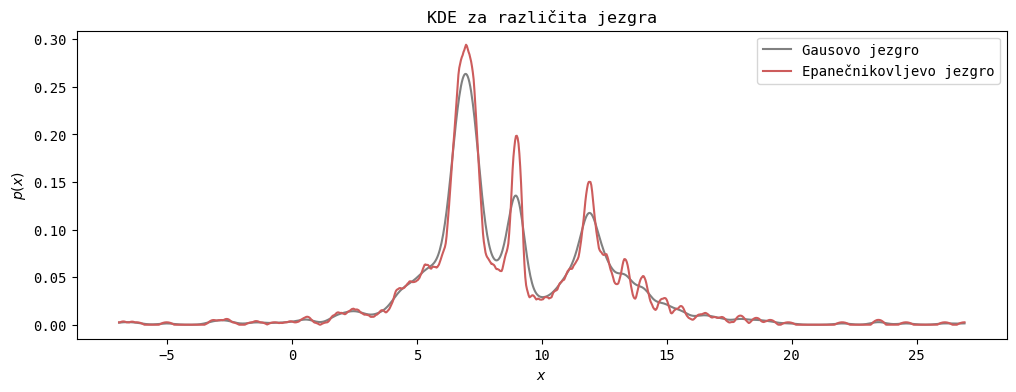

In [29]:
plt.figure(figsize=(12,4))
gaus = kde_sklearn(x, bandwidth=0.3, kernel="gaussian") 
epan = kde_sklearn(x, bandwidth=0.3, kernel="epanechnikov") 

plt.plot(xg, gaus, color='gray', label=r'Gausovo jezgro') 
plt.plot(xg, epan, color='indianred', label=r'Epanečnikovljevo jezgro')
plt.xlabel(r'$x$')
plt.ylabel(r'$p(x)$')
plt.title(r'KDE za različita jezgra')
plt.legend()
plt.show()  

---

Pošto se u astronomiji radi sa podacima koji su raspoređeni na više redova veličine, obično plotujemo u log-log skalama. Stepeni zakoni ($y\propto x^\alpha$) postaju ($\ln y \propto \alpha\ln x + \text{constant}$). Ako pretpostavimo da imamo šum u mjerenjima i da je on generisan tzv. gausovskim procesom, onda imamo $y_i = a x_i + b + r_i$, gdje je $r_i$ izvučeno iz $\mathcal{N}(0,\sigma)$. Model uključuje linearnu vezu sa dva parametra, $a$ i $b$ - dakle $M(a,b)$. Ukoliko računamo $L$, prvo pitanje koje se postavlja je koja je vjerovatnoća $p(y_i|x_i, M(a, b), \sigma)$ da se izmjeri $y_i$. Pišemo:

$$ 
p(y_i|x_i, M(a, b), \sigma) = N(y_i - M(x)|\sigma) = \frac{1}{\sqrt{2 \pi \sigma^2}} e^{- \frac{(y_i - M(x_i))^2}{2 \sigma^2}}. 
$$

Te dalje imamo:

$$
\ln{L(a, b)} = \mathrm{const.} - \frac{1}{2} \sum_{i=1}^N \frac{(y_i - M(x_i))^2}{\sigma^2} = \mathrm{const.} - \frac{1}{2} \chi^2.
$$

Maksimizaciju vršimo u odnosu na $a$ i $b$. Ovo je ekvivalentno minimizaciji $\chi^2$ u metodi najmanjih kvadarata.

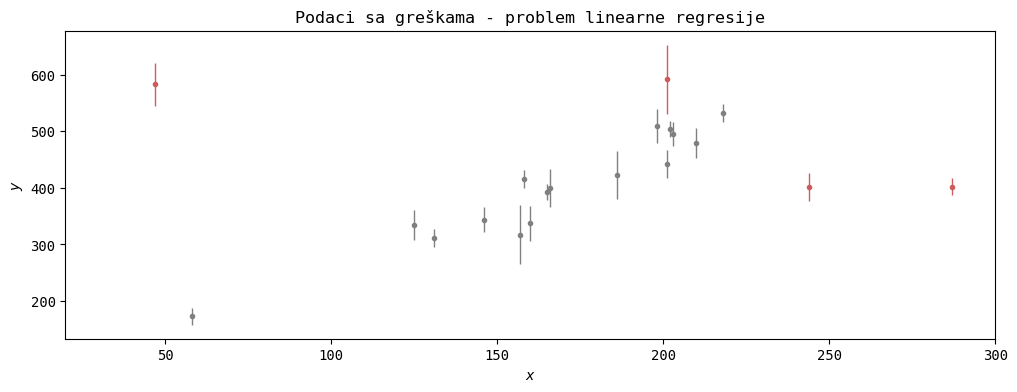

In [31]:
x = np.array([201, 244,  47, 287, 203,  58, 210, 202, 198, 158, 165, 201, 157, 131, 166, 160, 186, 125, 218, 146])
y = np.array([592, 401, 583, 402, 495, 173, 479, 504, 510, 416, 393, 442, 317, 311, 400, 337, 423, 334, 533, 344])
dy = np.array([61, 25, 38, 15, 21, 15, 27, 14, 30, 16, 14, 25, 52, 16, 34, 31, 42, 26, 16, 22])

plt.figure(figsize=(12, 4))
plt.errorbar(x[4:], y[4:], dy[4:], fmt='.', color='gray', lw=1, ecolor='gray')
plt.errorbar(x[:4], y[:4], dy[:4], fmt='.', color='indianred', lw=1, ecolor='indianred')
plt.xlim(20, 300)
plt.title(r'Podaci sa greškama - problem linearne regresije')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.show()

Optimization terminated successfully.
         Current function value: 18.680770
         Iterations: 53
         Function evaluations: 106


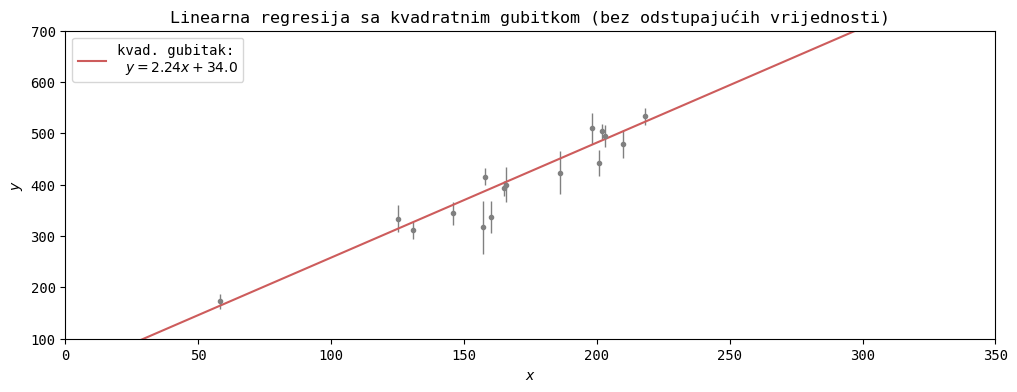

In [33]:
def sq_loss(m, b, x, y, dy):
    y_fit = m * x + b
    return np.sum(((y - y_fit) / dy) ** 2, -1)

f_sq = lambda beta: sq_loss(beta[0], beta[1], x=x[4:], y=y[4:], dy=dy[4:])
beta0 = (1, 30) # inicijalno m, b
beta_sq = optimize.fmin(f_sq, beta0)

x_fit = np.linspace(0, 350, 10)

plt.figure(figsize=(12, 4))
plt.errorbar(x[4:], y[4:], dy[4:], fmt='.', color='gray', lw=1, ecolor='gray')
plt.plot(x_fit, beta_sq[0] * x_fit + beta_sq[1], ls='-', color='indianred', label="kvad. gubitak:\n $y=%.2fx + %.1f$" % tuple(beta_sq))
plt.xlim(0, 350)
plt.ylim(100, 700)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(r'Linearna regresija sa kvadratnim gubitkom (bez odstupajućih vrijednosti)')
plt.legend()
plt.show()


Optimization terminated successfully.
         Current function value: 289.963723
         Iterations: 70
         Function evaluations: 133


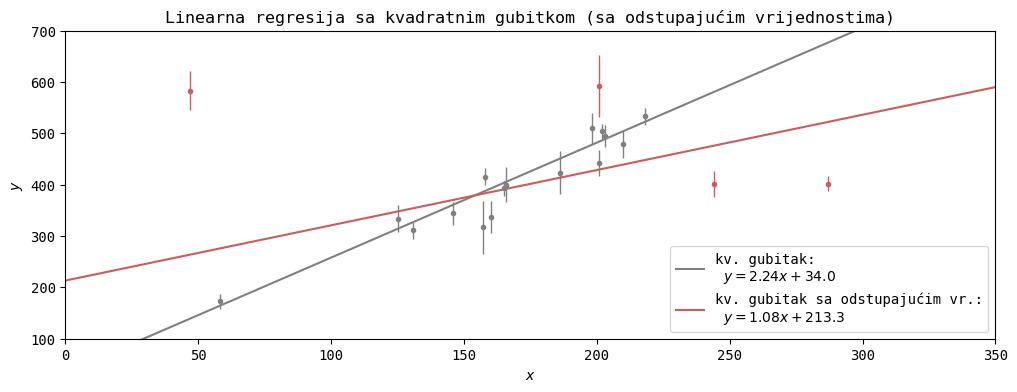

In [40]:
f_sq_outl = lambda beta: sq_loss(beta[0], beta[1], x=x, y=y, dy=dy)
beta_sq_outl = optimize.fmin(f_sq_outl, beta0)

plt.figure(figsize=(12, 4))
plt.errorbar(x[4:], y[4:], dy[4:], fmt='.', color='gray', lw=1, ecolor='gray')
plt.errorbar(x[:4], y[:4], dy[:4], fmt='.', color='indianred', lw=1, ecolor='indianred')
plt.plot(x_fit, beta_sq[0] * x_fit + beta_sq[1], ls='-', color='gray', label="kv. gubitak:\n $y=%.2fx + %.1f$" % tuple(beta_sq))
plt.plot(x_fit, beta_sq_outl[0] * x_fit + beta_sq_outl[1], ls='-', color='indianred', label="kv. gubitak sa odstupajućim vr.:\n $y=%.2fx + %.1f$" % tuple(beta_sq_outl))
plt.xlim(0, 350)
plt.ylim(100, 700)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(r'Linearna regresija sa kvadratnim gubitkom (sa odstupajućim vrijednostima)')
plt.legend()
plt.show()

Standardni pristup za smanjenje uticaja odstupajućih vrijednosti jeste modifikacija $L$ korišćenjem Huberove funkcije gubitka
$\sum_{i=1}^{N} e(y_i | y)$, gdje je:

$$
e(t) = \begin{cases} \frac{1}{2}t^2, & \text{ako } |t| \leq c, \\ c|t| - \frac{1}{2}c^2, & \text{ako } |t| \geq c, \end{cases}
$$

i takođe:

$$
t = \left|\frac{y - M(x)}{\sigma}\right|.
$$

Za male reziduale ($|t| \leq c$) funkcija se ponaša kao standardni $\chi^2$ ($L_2$ norma), a za velike vrijednosti ($|t| \geq c$) prelazi na $L_1$ normu $\left(\sum_{i=1}^N |y_i - M(x_i)|\right)$, čime se standardnim vrijednostima pridaje manja oteženjenost. Funkcija je neprekidna i diferencijabilna u tački $|t| = c$.

Optimization terminated successfully.
         Current function value: 43.439758
         Iterations: 62
         Function evaluations: 118


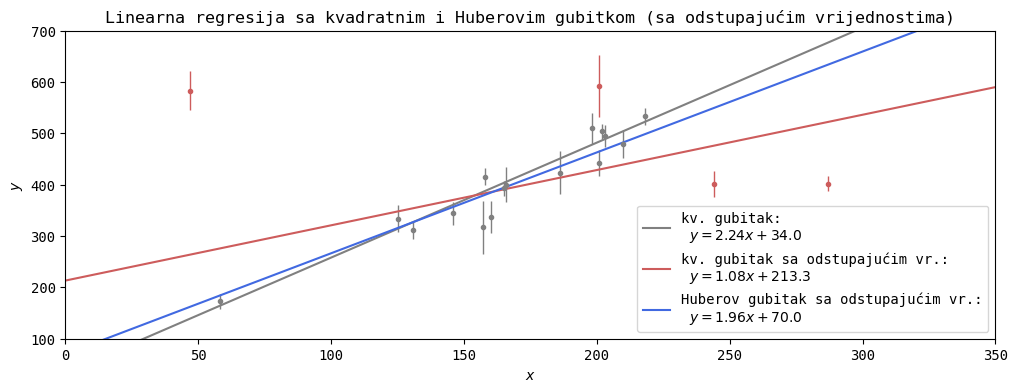

In [41]:
def huber_loss(m, b, x, y, dy, c=1):
    y_fit = m * x + b
    t = abs((y - y_fit) / dy)
    mask = t > c
    return np.sum(~mask * (0.5 * t ** 2) - mask * c * (0.5 * c - t), -1)

c = 1
f_huber = lambda beta: huber_loss(beta[0], beta[1], x=x, y=y, dy=dy, c=c)
beta0 = (1, 30)
beta_huber = optimize.fmin(f_huber, beta0)

x_fit = np.linspace(0, 350, 10)

plt.figure(figsize=(12, 4))
plt.errorbar(x[4:], y[4:], dy[4:], fmt='.', color='gray', lw=1, ecolor='gray')
plt.errorbar(x[:4], y[:4], dy[:4], fmt='.', color='indianred', lw=1, ecolor='indianred')
plt.plot(x_fit, beta_sq[0] * x_fit + beta_sq[1], color='gray', label="kv. gubitak:\n $y=%.2fx + %.1f$" % tuple(beta_sq))
plt.plot(x_fit, beta_sq_outl[0] * x_fit + beta_sq_outl[1], color='indianred', label="kv. gubitak sa odstupajućim vr.:\n $y=%.2fx + %.1f$" % tuple(beta_sq_outl))
plt.plot(x_fit, beta_huber[0] * x_fit + beta_huber[1], color='royalblue', label="Huberov gubitak sa odstupajućim vr.:\n $y=%.2fx + %.1f$" % tuple(beta_huber))
plt.xlim(0, 350)
plt.ylim(100, 700)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(r'Linearna regresija sa kvadratnim i Huberovim gubitkom (sa odstupajućim vrijednostima)')
plt.legend()
plt.show()